# ARK Invest: Skill or Luck?

In [1]:
# ── Librerie base ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizzazione ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Econometria / Statistica ───────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS
from statsmodels.datasets import longley
from statsmodels.iolib.summary2 import summary_col
from statsmodels.tsa.stattools import adfuller

from scipy import stats
from scipy.stats import norm, linregress

# ── Machine Learning / PCA / Clustering ───────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# ── Ottimizzazione portafoglio ─────────────────────────────────────────────────
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# ── Dati finanziari ────────────────────────────────────────────────────────────
import yfinance as yf
import fmfinance as fm
import financedatabase as fd
import quantstats as qs

# ── Calcolo parallelo ──────────────────────────────────────────────────────────
from joblib import Parallel, delayed

# ── Interfaccia R ──────────────────────────────────────────────────────────────
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# ── Trading algoritmico (Alpaca) ───────────────────────────────────────────────
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest, LimitOrderRequest, ClosePositionRequest
from alpaca.trading.enums import OrderSide, TimeInForce
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockLatestTradeRequest, StockLatestQuoteRequest

# ── Web scraping ───────────────────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
from io import StringIO

# ── UI interattiva ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display

# ── Utility ────────────────────────────────────────────────────────────────────
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
import random
import time
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Setup

In [2]:
start = '2019-01-01'
end = '2024-12-31'
split = '2022-12-31'

ff4f = fm.ff('4_factors', start, end)[0]

tickers = ['ARKK', 'ARKW', 'ARKG', 'ARKF', 'ARKQ', 'SPY']
prices = yf.download(tickers, start=start, end=end,
                     auto_adjust=False, multi_level_index=False, interval='1mo')['Adj Close']

display(ff4f)
display(prices)

[*********************100%***********************]  6 of 6 completed


,Mkt-RF,SMB,HML,Mom,RF
Date,,,,,
2019-01-01,8.37,2.76,-0.39,-8.62,0.21
2019-02-01,3.42,2.05,-2.66,0.50,0.18
2019-03-01,1.10,-3.03,-4.14,2.24,0.19
2019-04-01,3.97,-1.74,2.13,-2.91,0.21
2019-05-01,-6.92,-1.26,-2.45,7.55,0.21
...,...,...,...,...,...
2024-08-01,1.60,-3.50,-1.10,4.86,0.48
2024-09-01,1.72,-0.12,-2.77,-0.56,0.40
2024-10-01,-1.00,-0.96,0.89,2.94,0.39


Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-01-01,NaN,27.011171,41.523792,32.629162,46.841202,242.095963
2019-02-01,20.852493,29.461514,44.909355,34.610851,49.130287,249.943695
2019-03-01,21.196594,31.471558,45.073334,33.394367,49.007328,253.351959
2019-04-01,22.278053,31.308838,45.545963,33.959446,50.482937,264.863464
2019-05-01,20.685360,27.872620,39.286045,28.783512,45.015606,247.972839
...,...,...,...,...,...,...
2024-08-01,28.275276,26.389999,44.820000,56.085991,77.984314,552.062927
2024-09-01,29.793949,25.600000,47.529999,60.763977,83.833870,561.935181
2024-10-01,30.843033,23.139999,45.889999,60.823826,85.636009,558.629028


In [3]:
returns    = prices.pct_change()*100
returns.dropna(inplace=True)
returns

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.650167,6.822610,0.365132,-3.514748,-0.250272,1.363613
2019-04-01,5.102042,-0.517037,1.048579,1.692138,3.010996,4.543681
2019-05-01,-7.149158,-10.975234,-13.744178,-15.241514,-10.830057,-6.377106
2019-06-01,7.652092,18.372261,17.800136,15.064758,9.287661,6.440948
2019-07-01,0.958059,0.319111,1.000423,-2.073456,0.903675,2.005634
...,...,...,...,...,...,...
2024-08-01,3.967675,-2.077927,-1.559409,-0.530686,1.799718,2.336543
2024-09-01,5.371028,-2.993554,6.046406,8.340739,7.500939,1.788248
2024-10-01,3.521130,-9.609379,-3.450451,0.098494,2.149655,-0.588351


In [4]:
rf = ff4f['RF']
er = returns.subtract(rf, axis=0).dropna()

display(er.round(2))

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.46,6.63,0.18,-3.70,-0.44,1.17
2019-04-01,4.89,-0.73,0.84,1.48,2.80,4.33
2019-05-01,-7.36,-11.19,-13.95,-15.45,-11.04,-6.59
2019-06-01,7.47,18.19,17.62,14.88,9.11,6.26
2019-07-01,0.77,0.13,0.81,-2.26,0.71,1.82
...,...,...,...,...,...,...
2024-08-01,3.49,-2.56,-2.04,-1.01,1.32,1.86
2024-09-01,4.97,-3.39,5.65,7.94,7.10,1.39
2024-10-01,3.13,-10.00,-3.84,-0.29,1.76,-0.98


## Return Analysis

In [30]:
# ── Statistiche descrittive comparative (Fase 1) ──────────────────────────────
# Tutti gli ETF + SPY, dati mensili → periods_per_year=12
# Pattern ripreso da Es01_Return_Analysis.ipynb

etf_tickers = ['ARKF', 'ARKG', 'ARKK', 'ARKQ', 'ARKW']

# Rendimenti in eccesso in formato decimale per quantstats
er_qs = er[etf_tickers] / 100

# Loop su ogni strumento per raccogliere le metriche
statistiche = {}

for ticker in etf_tickers:
    rets = er_qs[ticker].dropna()
    statistiche[ticker] = {
        'Media mensile (%)':    round(er[ticker].mean(), 3),
        'Std. Dev. mensile (%)': round(er[ticker].std(), 3),
        'Skewness':             round(er[ticker].skew(), 3),
        'Curtosi (excess)':     round(er[ticker].kurt(), 3),
        'Min (%)':              round(er[ticker].min(), 3),
        'Max (%)':              round(er[ticker].max(), 3),
        'CAGR (%)': round(qs.stats.cagr(rets, periods=12) * 100, 3),
        'Volatilità ann. (%)':  round(qs.stats.volatility(rets, periods=12) * 100, 3),
        'Sharpe (ann.)':        round(qs.stats.sharpe(rets, periods=12), 3),
        'Sortino (ann.)':       round(qs.stats.sortino(rets, periods=12), 3),
        'Max Drawdown (%)':     round(qs.stats.max_drawdown(rets) * 100, 3),
        'VaR 5% (%)':           round(qs.stats.value_at_risk(rets, sigma=0.05) * 100, 3),
        'CVaR 5% (%)':          round(qs.stats.cvar(rets, confidence=0.95) * 100, 3),
    }

# Costruzione DataFrame trasposto (metriche per riga, ETF per colonna)
df_stats = pd.DataFrame(statistiche)
display(df_stats)

,ARKF,ARKG,ARKK,ARKQ,ARKW
Media mensile (%),1.255,0.152,0.880,1.339,1.570
Std. Dev. mensile (%),11.314,11.705,12.379,8.931,11.617
Skewness,0.199,0.292,0.372,0.364,0.218
Curtosi (excess),0.231,-0.401,-0.177,-0.107,-0.156
Min (%),-27.022,-25.974,-28.903,-16.302,-26.542
Max (%),29.737,30.083,31.002,25.477,28.807
CAGR (%),7.844,-6.023,1.709,12.088,11.570
Volatilità ann. (%),39.194,40.548,42.883,30.937,40.244
Sharpe (ann.),0.384,0.045,0.246,0.519,0.468
Sortino (ann.),0.617,0.069,0.404,0.901,0.777


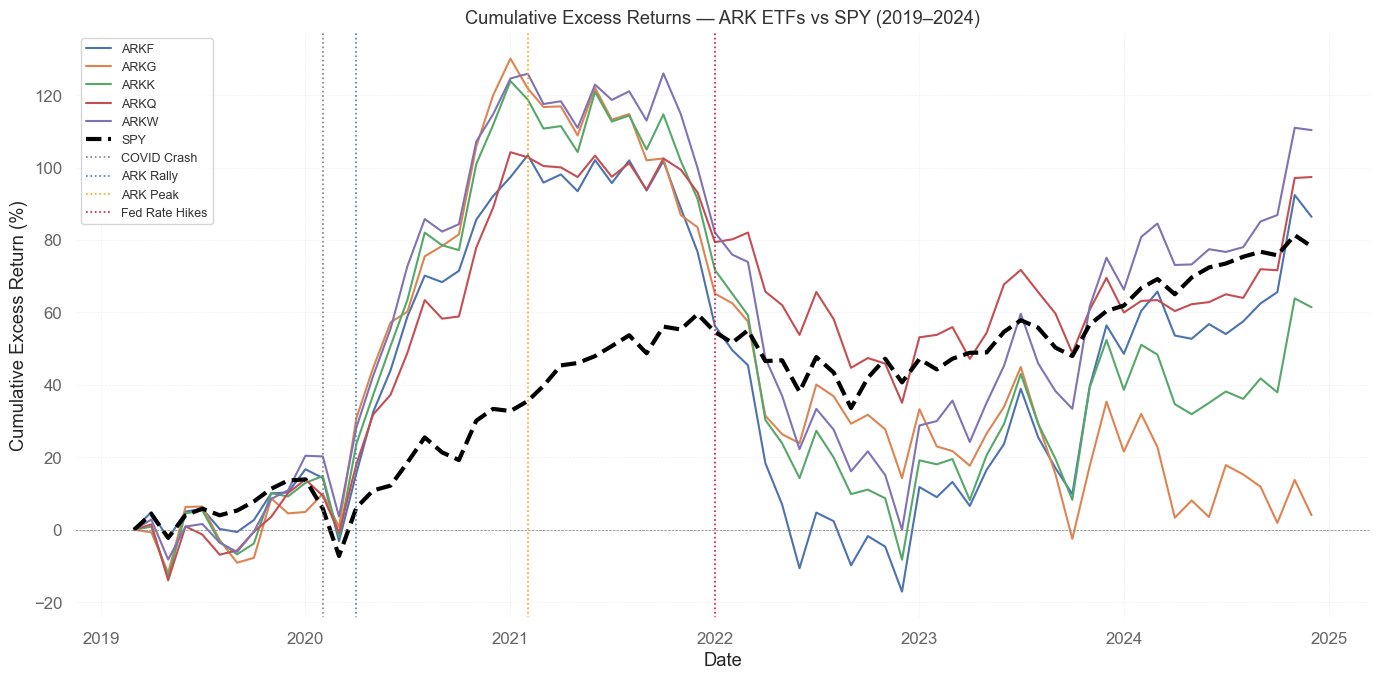

In [31]:
# Rendimenti cumulati
cum_er = er[etf_tickers + ['SPY']].cumsum()
cum_er = cum_er - cum_er.bfill().iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))

# ETF ARK
for ticker in etf_tickers:
    ax.plot(cum_er.index, cum_er[ticker], label=ticker, linewidth=1.5)

# SPY evidenziato
ax.plot(cum_er.index, cum_er['SPY'], label='SPY', linewidth=3, 
        color='black', linestyle='--')

# Linee verticali
ax.axvline(pd.Timestamp('2020-02-01'), color='gray',     linestyle=':', linewidth=1.2, label='COVID Crash')
ax.axvline(pd.Timestamp('2020-04-01'), color='steelblue',linestyle=':', linewidth=1.2, label='ARK Rally')
ax.axvline(pd.Timestamp('2021-02-01'), color='orange',   linestyle=':', linewidth=1.2, label='ARK Peak')
ax.axvline(pd.Timestamp('2022-01-01'), color='crimson',  linestyle=':', linewidth=1.2, label='Fed Rate Hikes')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Cumulative Excess Returns — ARK ETFs vs SPY (2019–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Excess Return (%)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Il grafico mostra l'evoluzione dei rendimenti cumulati in eccesso per i cinque ETF
ARK e il benchmark SPY sull'intero periodo di analisi.

Fino al COVID crash (febbraio 2020) tutti gli strumenti si muovono in modo simile
e contenuto. Dal rimbalzo di aprile 2020 i fondi ARK accelerano bruscamente rispetto
a SPY, raggiungendo rendimenti cumulati di oltre 120–140% al picco di febbraio 2021,
mentre SPY si fermava intorno al 60%.

Con l'inversione di tendenza del 2022 — accentuata dai rialzi dei tassi Fed — i fondi
ARK restituiscono quasi interamente i guadagni accumulati, scendendo in alcuni casi
sotto zero (ARKF). SPY mostra invece un drawdown molto più contenuto (~-24%).

Nel biennio 2023–2024 si assiste a una parziale ripresa, con ARKW e ARKQ che
recuperano terreno, mentre ARKG rimane il fondo più debole dell'universo.

La correlazione visiva molto elevata tra i cinque ETF ARK conferma quanto emerso
dalla matrice di correlazione: i fondi condividono un'esposizione comune che li rende
sostanzialmente intercambiabili in termini di profilo rischio-rendimento.

In [32]:
display(er.round(2))

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.46,6.63,0.18,-3.70,-0.44,1.17
2019-04-01,4.89,-0.73,0.84,1.48,2.80,4.33
2019-05-01,-7.36,-11.19,-13.95,-15.45,-11.04,-6.59
2019-06-01,7.47,18.19,17.62,14.88,9.11,6.26
2019-07-01,0.77,0.13,0.81,-2.26,0.71,1.82
...,...,...,...,...,...,...
2024-08-01,3.49,-2.56,-2.04,-1.01,1.32,1.86
2024-09-01,4.97,-3.39,5.65,7.94,7.10,1.39
2024-10-01,3.13,-10.00,-3.84,-0.29,1.76,-0.98


In [33]:
# Matrice di correlazione
er[etf_tickers].corr().style.background_gradient(cmap='coolwarm', vmin=0, vmax=1)

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW
Ticker,,,,,
ARKF,1.000000,0.816518,0.937567,0.862174,0.971968
ARKG,0.816518,1.000000,0.912701,0.807723,0.834143
ARKK,0.937567,0.912701,1.000000,0.914741,0.967251
ARKQ,0.862174,0.807723,0.914741,1.000000,0.901813
ARKW,0.971968,0.834143,0.967251,0.901813,1.000000


Nonostante i diversi temi dichiarati (genomica, fintech, robotica…), i cinque fondi condividono un'esposizione fattoriale comune talmente forte, alta esposizione a Mkt-RF, SMB positivo, HML negativo, da renderli sostanzialmente intercambiabili dal punto di vista del profilo rischio-rendimento. 

## Carhart 

In [34]:
# Allineamento fattori e excess returns — solo periodo in-sample
capm4 = pd.concat([ff4f, er], axis=1).dropna()
capm4_is = capm4.loc[:split]

x1 = capm4_is[['Mkt-RF', 'SMB', 'HML', 'Mom']]
x  = sm.add_constant(x1)
y  = capm4_is[etf_tickers]

# Regressioni OLS — modello Carhart a 4 fattori
regr_4f = []
for i in range(len(y.columns)):
    regr_4f.append(sm.OLS(y.iloc[:, i], x).fit())

summary_col(regr_4f, stars=True)

,ARKF,ARKG,ARKK,ARKQ,ARKW
const,-1.4869**,0.0620,-1.1241,-0.2403,-1.1284
,(0.7311),(0.8057),(0.7940),(0.5576),(0.7852)
Mkt-RF,1.4779***,1.1327***,1.5141***,1.2487***,1.5252***
,(0.1439),(0.1585),(0.1562),(0.1097),(0.1545)
SMB,1.1277***,1.6153***,1.4612***,1.1960***,1.2900***
,(0.2829),(0.3117),(0.3072),(0.2157),(0.3038)
HML,-0.5102***,-0.9689***,-0.7952***,-0.3347***,-0.6250***
,(0.1566),(0.1726),(0.1701),(0.1195),(0.1682)
Mom,0.3357,-0.2385,0.0995,0.2112,0.2988
,(0.2158),(0.2378),(0.2344),(0.1646),(0.2318)


In [37]:
for i, ticker in enumerate(etf_tickers):
    print(f"{ticker} — F-stat: {regr_4f[i].fvalue:.2f}, p-value: {regr_4f[i].f_pvalue:.2e}")

ARKF — F-stat: 44.81, p-value: 1.91e-14
ARKG — F-stat: 43.19, p-value: 3.50e-14
ARKK — F-stat: 50.58, p-value: 2.53e-15
ARKQ — F-stat: 60.30, p-value: 1.24e-16
ARKW — F-stat: 44.68, p-value: 2.00e-14


**Alpha (const)** — solo ARKF mostra un alpha statisticamente significativo (-1.49**, 
pari a circa -18% annuo). Gli alpha degli altri fondi sono negativi ma non significativi: 
non si può escludere che siano rumore statistico. Il risultato chiave è che **nessun 
fondo genera alpha positivo significativo** — la performance è prevalentemente 
attribuibile alle esposizioni fattoriali sistematiche.

**Beta di mercato (Mkt-RF)** — tutti i coefficienti sono positivi, compresi tra 1.13 
(ARKG) e 1.52 (ARKW), e significativi al 99%. Tutti i fondi ARK amplificano i movimenti 
di mercato: un rialzo del 10% del mercato si traduce in un guadagno di circa 13–15% 
per gli ETF ARK. Questo implica che buona parte della performance straordinaria del 
2020 era semplicemente il mercato che saliva, amplificato dal beta elevato.

**SMB** — tutti positivi e significativi al 99%, compresi tra 1.13 (ARKF) e 1.62 (ARKG). 
I fondi ARK si comportano come portafogli di small cap: quando le piccole capitalizzazioni 
sovraperformano le grandi, gli ETF ARK ne beneficiano in modo amplificato. Coerente con 
la strategia di investire in aziende innovative giovani e di piccola/media dimensione.

**HML** — tutti negativi e significativi al 99%, compresi tra -0.33 (ARKQ) e -0.97 (ARKG). 
Conferma strutturalmente l'impronta growth di ARK: i fondi sovrappesano titoli con alto 
price-to-book e basso valore contabile, ovvero l'opposto dei titoli value.

**Mom** — nessun coefficiente è significativo. Il fattore momentum non contribuisce 
a spiegare i rendimenti ARK nel periodo in-sample.

**R²** — tutti intorno a 0.81. Circa l'80% della variabilità mensile dei rendimenti 
è spiegata dai quattro fattori. Lo spazio per lo stock-picking idiosincratico è limitato.

## Rolling Analysis

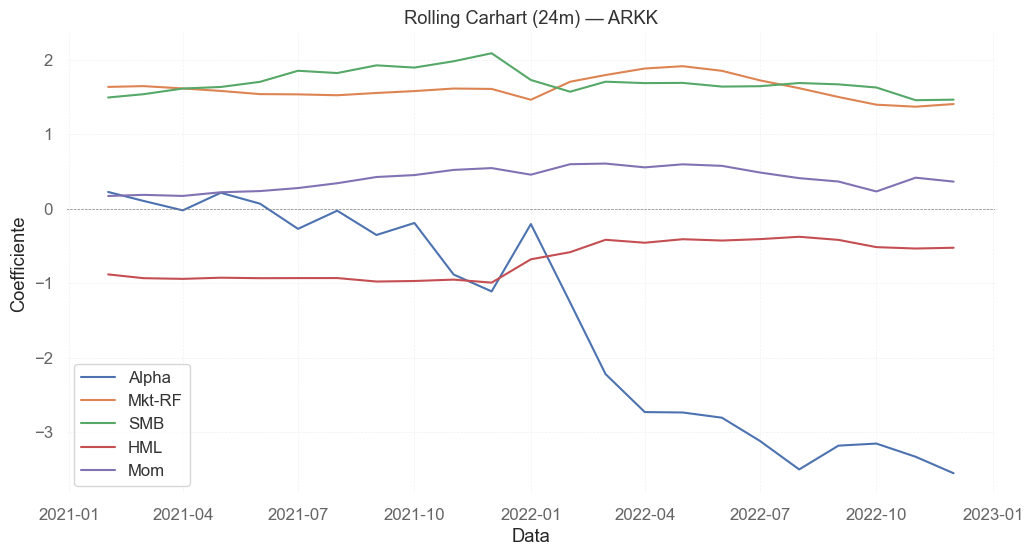

In [35]:
# Stima rolling 24 mesi — ARKK
m1_rolling = RollingOLS(capm4_is['ARKK'], x, window=24).fit()
params = m1_rolling.params

# Grafico
plt.figure(figsize=(12, 6))
plt.plot(params.index, params['const'],  label='Alpha',  linewidth=1.5)
plt.plot(params.index, params['Mkt-RF'], label='Mkt-RF', linewidth=1.5)
plt.plot(params.index, params['SMB'],    label='SMB',    linewidth=1.5)
plt.plot(params.index, params['HML'],    label='HML',    linewidth=1.5)
plt.plot(params.index, params['Mom'],    label='Mom',    linewidth=1.5)

plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.title('Rolling Carhart (24m) — ARKK')
plt.xlabel('Data')
plt.ylabel('Coefficiente')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

La regressione Carhart stimata su finestra mobile di 24 mesi permette di osservare
come le esposizioni fattoriali di ARKK si sono evolute nel tempo.

**Mkt-RF** e **SMB** risultano stabili per tutto il periodo (rispettivamente ~1.5 e ~1.7),
confermando un'esposizione persistente al mercato e alle small cap indipendentemente
dal regime.

**HML** rimane costantemente negativo (~-1), coerente con l'impronta growth della
strategia ARK: il fondo sovrapesa titoli a basso book-to-market.

**Mom** rimane vicino a zero per tutto il periodo, con una leggera risalita verso
fine 2022, il fattore momentum non sembra essere un driver rilevante per ARKK.

La serie più informativa è **Alpha**: positivo e stabile fino a metà 2021, crolla
drasticamente fino a -3.5 nel corso del 2022. Questo indica che, una volta entrati
nel regime bear, i rendimenti di ARKK non solo erano spiegati dai fattori sistematici,
ma mostravano una distruzione di valore idiosincratica persistente, la performance
negativa non era interamente attribuibile alle esposizioni fattoriali.

## Bootstrap

In [38]:
# Fattori e fondi in-sample
factors_is = capm4_is[['Mkt-RF', 'SMB', 'HML', 'Mom']]
funds_is   = capm4_is[etf_tickers]

# Bootstrap cross-sezionale — Cuthbertson et al. (2008)
np.random.seed(42)
alpha_obs, alpha_t_obs, alphas_boot, t_alphas_boot = fm.bootstrap(
    factors_is,
    funds_is,
    n_boot=1000,
    min_obs=24
)